In [1]:
# ── Cell 1: Imports & Config ──────────────────────────────────

import numpy as np
import pandas as pd
from collections import Counter
import re, os, random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

# Reproducibility — critical for comparing experiments
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device: Kaggle gives you a free GPU — always use it!
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ── Hyperparameters (change these to experiment) ──
CONFIG = {
    "max_vocab"    : 30000,   # keep only top 30k words
    "max_len_prompt": 64,     # pad/truncate prompt to 64 tokens
    "max_len_option": 128,    # pad/truncate each option to 128 tokens
    "embed_dim"    : 128,     # word embedding size
    "hidden_dim"   : 256,     # LSTM hidden units (each direction)
    "num_layers"   : 2,       # stacked LSTM layers
    "dropout"      : 0.3,     # dropout for regularisation
    "batch_size"   : 32,
    "epochs"       : 10,
    "lr"           : 3e-4,    # learning rate (Adam)
    "grad_clip"    : 1.0,     # gradient clipping threshold
}

print("Config loaded:", CONFIG)

Using device: cuda
Config loaded: {'max_vocab': 30000, 'max_len_prompt': 64, 'max_len_option': 128, 'embed_dim': 128, 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.3, 'batch_size': 32, 'epochs': 10, 'lr': 0.0003, 'grad_clip': 1.0}


In [2]:
train_df = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv')
sample_df = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv')

print(f"train_df: {train_df.shape}  |  test_df: {test_df.shape}")
print(f"\nAnswer distribution:\n{train_df['answer'].value_counts().sort_index()}")
print(f"\nSample row:\n{train_df.iloc[0]}")

train_df: (2000, 8)  |  test_df: (500, 7)

Answer distribution:
answer
A    369
B    490
C    459
D    358
E    324
Name: count, dtype: int64

Sample row:
id                                                        1
prompt    Pick the best possible answer: What is Martin ...
A         Martin Heidegger believes that humans exist wi...
B         Martin Heidegger believes that humans do not e...
C         Martin Heidegger does not believe in the exist...
D         Martin Heidegger believes that the relationshi...
E         Martin Heidegger believes that time is an illu...
answer                                                    B
Name: 0, dtype: object


In [3]:
# ── Cell 3: Tokenizer ─────────────────────────────────────────
#
# A tokenizer converts raw text → list of integer IDs.
# We build it from scratch so you understand exactly what's happening.
#
# Steps:
#   1. Clean text (lowercase, remove special chars)
#   2. Split into words (tokens)
#   3. Count all words across ALL training text
#   4. Keep the top-N most frequent → vocabulary
#   5. Assign each word a unique integer ID
#
# Special tokens:
#   <PAD> = 0  → used to pad short sequences to equal length
#   <UNK> = 1  → any word not in vocabulary maps here

def clean_text(text):
    """Lowercase and remove non-alphanumeric chars (keep spaces)."""
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    """Split cleaned text into a list of word tokens."""
    return clean_text(text).split()


class Vocabulary:
    """
    Maps words ↔ integer IDs.

    PAD_ID = 0  (padding, contributes nothing to the model)
    UNK_ID = 1  (unknown words not seen during training)
    """
    PAD_ID = 0
    UNK_ID = 1

    def __init__(self, max_vocab=30000):
        self.max_vocab  = max_vocab
        self.word2id    = {"<PAD>": 0, "<UNK>": 1}
        self.id2word    = {0: "<PAD>", 1: "<UNK>"}

    def build(self, texts):
        """
        Count all words across all texts, keep top max_vocab.
        texts: list of raw strings
        """
        counter = Counter()
        for text in texts:
            counter.update(tokenize(text))

        # Sort by frequency, keep most common
        most_common = counter.most_common(self.max_vocab - 2)  # -2 for PAD, UNK
        for idx, (word, _) in enumerate(most_common, start=2):
            self.word2id[word] = idx
            self.id2word[idx]  = word

        print(f"Vocabulary built: {len(self.word2id):,} words")
        print(f"  Most common: {[w for w, _ in most_common[:10]]}")

    def encode(self, text, max_len):
        """
        Convert a string to a padded list of integer IDs.

        1. Tokenize → ["what", "is", "quantum", ...]
        2. Map each word to its ID (UNK if not found)
        3. Truncate to max_len if too long
        4. Pad with 0s if shorter than max_len
        5. Also return actual length (before padding) for LSTM
        """
        tokens = tokenize(text)
        ids    = [self.word2id.get(w, self.UNK_ID) for w in tokens]
        ids    = ids[:max_len]           # truncate
        length = len(ids)               # real length before padding
        ids   += [self.PAD_ID] * (max_len - length)  # pad
        return ids, length


# Build vocabulary from all training text
all_texts = []
for _, row in train_df.iterrows():
    all_texts.append(row["prompt"])
    for opt in "ABCDE":
        all_texts.append(str(row[opt]))

vocab = Vocabulary(max_vocab=CONFIG["max_vocab"])
vocab.build(all_texts)

Vocabulary built: 2,975 words
  Most common: ['the', 'of', 'a', 'is', 'and', 'in', 'to', 'that', 'by', 'an']


In [4]:
# ── Cell 4: PyTorch Dataset ───────────────────────────────────
#
# PyTorch's Dataset class defines HOW to load one sample.
# DataLoader then batches them efficiently and shuffles.
#
# Each sample = one question with 5 options.
# Label = index 0–4 (A=0, B=1, C=2, D=3, E=4)

LABEL_MAP = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4}

class MCQDataset(Dataset):
    def __init__(self, df, vocab, cfg, has_labels=True):
        self.df         = df.reset_index(drop=True)
        self.vocab      = vocab
        self.cfg        = cfg
        self.has_labels = has_labels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Encode the prompt
        p_ids, p_len = self.vocab.encode(
            row["prompt"], self.cfg["max_len_prompt"]
        )

        # Encode each of the 5 options
        opt_ids, opt_lens = [], []
        for opt in "ABCDE":
            ids, length = self.vocab.encode(
                str(row[opt]), self.cfg["max_len_option"]
            )
            opt_ids.append(ids)
            opt_lens.append(length)

        sample = {
            "prompt_ids"  : torch.tensor(p_ids,    dtype=torch.long),
            "prompt_len"  : torch.tensor(p_len,    dtype=torch.long),
            # Shape: (5, max_len_option)
            "option_ids"  : torch.tensor(opt_ids,  dtype=torch.long),
            "option_lens" : torch.tensor(opt_lens, dtype=torch.long),
        }

        if self.has_labels:
            label = LABEL_MAP[row["answer"]]
            sample["label"] = torch.tensor(label, dtype=torch.long)

        return sample


# Create train/val split (80/20)
val_size  = int(0.2 * len(train_df))
train_df  = train_df.iloc[:-val_size].reset_index(drop=True)
val_df    = train_df.iloc[-val_size:].reset_index(drop=True)

train_ds  = MCQDataset(train_df, vocab, CONFIG, has_labels=True)
val_ds    = MCQDataset(val_df,   vocab, CONFIG, has_labels=True)
test_ds   = MCQDataset(test_df,     vocab, CONFIG, has_labels=False)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"],
                          shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=2)

print(f"train_df batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"test_df  batches : {len(test_loader)}")

train_df batches : 50
Val   batches : 13
test_df  batches : 16


In [5]:
# ── Cell 5: Bi-LSTM Model ─────────────────────────────────────
#
# ARCHITECTURE WALKTHROUGH
# ────────────────────────
#
# Step 1 — Embedding layer
#   Word IDs → dense vectors of size embed_dim.
#   e.g. word "quantum" → [0.23, -0.11, 0.87, ...]
#   These vectors are LEARNED during training.
#   Padding (ID=0) is masked → contributes zero gradient.
#
# Step 2 — Bi-LSTM encoder
#   Processes the sequence of embeddings.
#   Forward LSTM reads left→right.
#   Backward LSTM reads right→left.
#   At each position t: hidden_t = [h_forward_t ; h_backward_t]
#   → size 2 * hidden_dim
#
#   We take the FINAL hidden state as the sentence representation.
#   For a Bi-LSTM: we concatenate the last forward hidden state
#   and the last backward hidden state → size 2 * hidden_dim.
#
# Step 3 — pack_padded_sequence
#   Tells the LSTM to skip computation on PAD tokens.
#   This is critical for efficiency and correctness —
#   you don't want the PAD zeros to affect the hidden state.
#
# Step 4 — Siamese encoding
#   The SAME encoder (same weights) is applied to the prompt
#   AND to each of the 5 options. This is the "Siamese" part.
#   Weight sharing means we learn ONE good text encoder.
#
# Step 5 — Scoring head
#   For each option i:
#     interaction = [prompt_repr ; option_i_repr ; prompt_repr - option_i_repr]
#     score_i     = MLP(interaction) → scalar
#   We pass all 5 scores through softmax → probabilities.
#   The model is trained with CrossEntropyLoss.
#
# WHY SUBTRACTION? prompt_repr - option_i_repr highlights the
# *difference* between prompt and option. If they're very similar
# in embedding space, the difference is near-zero. This helps
# the model detect "how much does this option match the prompt?"

class TextEncoder(nn.Module):
    """Encodes a variable-length token sequence into a fixed vector."""

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout, pad_id=0):
        super().__init__()

        # Embedding: vocab_size rows, each is a learnable embed_dim vector
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_id       # PAD tokens always embed to zero
        )

        # Bi-LSTM: bidirectional=True doubles the output hidden size
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,        # input shape: (batch, seq_len, embed)
            bidirectional=True,      # forward + backward pass
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout   = nn.Dropout(dropout)
        self.output_dim = hidden_dim * 2  # because bidirectional

    def forward(self, token_ids, lengths):
        """
        token_ids : (batch, max_len)  — padded integer sequences
        lengths   : (batch,)          — real length of each sequence
        returns   : (batch, hidden_dim*2)
        """
        # 1. Embed tokens
        emb = self.dropout(self.embedding(token_ids))  # (B, L, E)

        # 2. Pack padded sequences so LSTM ignores PAD positions
        #    enforce_sorted=False lets us skip sorting by length
        packed = pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        # 3. Run LSTM
        _, (hidden, _) = self.lstm(packed)
        # hidden shape: (num_layers * 2, batch, hidden_dim)
        # We want the final layer's forward and backward states

        # num_layers * 2 directions → take last two (final layer)
        # hidden[-2] = final layer, forward direction
        # hidden[-1] = final layer, backward direction
        h_fwd = hidden[-2]  # (batch, hidden_dim)
        h_bwd = hidden[-1]  # (batch, hidden_dim)

        # Concatenate → full bidirectional representation
        repr = torch.cat([h_fwd, h_bwd], dim=-1)  # (batch, hidden_dim*2)
        return self.dropout(repr)


class BiLSTMSiamese(nn.Module):
    """
    Siamese Bi-LSTM for multiple choice question answering.
    One shared encoder for prompt and all options.
    Scoring MLP produces a logit per option.
    """

    def __init__(self, vocab_size, cfg):
        super().__init__()

        self.encoder = TextEncoder(
            vocab_size  = vocab_size,
            embed_dim   = cfg["embed_dim"],
            hidden_dim  = cfg["hidden_dim"],
            num_layers  = cfg["num_layers"],
            dropout     = cfg["dropout"],
        )

        enc_dim = self.encoder.output_dim  # hidden_dim * 2

        # Scoring head: takes [prompt ; option ; prompt - option]
        # Input size = 3 * enc_dim
        self.scorer = nn.Sequential(
            nn.Linear(3 * enc_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(cfg["dropout"]),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(cfg["dropout"]),
            nn.Linear(128, 1)   # scalar score per option
        )

    def forward(self, prompt_ids, prompt_len, option_ids, option_lens):
        """
        prompt_ids  : (batch, max_len_prompt)
        prompt_len  : (batch,)
        option_ids  : (batch, 5, max_len_option)
        option_lens : (batch, 5)
        returns     : (batch, 5) logits, one per option
        """
        batch_size = prompt_ids.size(0)

        # Encode the prompt once
        p_repr = self.encoder(prompt_ids, prompt_len)  # (B, enc_dim)

        # Encode all 5 options
        logits = []
        for i in range(5):
            opt_repr = self.encoder(
                option_ids[:, i, :],   # (B, max_len_option)
                option_lens[:, i]      # (B,)
            )   # → (B, enc_dim)

            # Build interaction vector
            interaction = torch.cat([
                p_repr,
                opt_repr,
                p_repr - opt_repr      # difference highlights mismatch
            ], dim=-1)                 # (B, 3 * enc_dim)

            score = self.scorer(interaction)  # (B, 1)
            logits.append(score)

        logits = torch.cat(logits, dim=-1)  # (B, 5)
        return logits


# Instantiate model
model = BiLSTMSiamese(
    vocab_size = len(vocab.word2id),
    cfg        = CONFIG
).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,}")
print(model)

Model parameters: 3,602,049
BiLSTMSiamese(
  (encoder): TextEncoder(
    (embedding): Embedding(2975, 128, padding_idx=0)
    (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (scorer): Sequential(
    (0): Linear(in_features=1536, out_features=512, bias=True)
    (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [6]:
# ── Cell 6: Training Loop ─────────────────────────────────────
#
# CrossEntropyLoss:
#   Takes raw logits (B, 5) and integer labels (B,).
#   Internally applies softmax, then computes log-loss.
#   It penalises the model more when it's confidently wrong.
#
# Adam optimiser:
#   Adapts learning rate per parameter using momentum.
#   Much better than plain SGD for NLP tasks.
#
# Gradient clipping:
#   LSTMs can suffer from "exploding gradients" — the gradient
#   grows exponentially through time steps.
#   Clipping norm to 1.0 prevents this.
#
# MAP@3 (not accuracy!):
#   We evaluate using the competition metric, not accuracy.
#   Accuracy = is rank-1 prediction correct?
#   MAP@3 = does correct answer appear in top-3, weighted by rank?

def map_at_3_torch(logits, labels):
    """
    Compute MAP@3 from model logits and true label indices.
    logits: (B, 5)  labels: (B,) integer 0-4
    """
    idx_map = ["A","B","C","D","E"]
    ranked  = torch.argsort(logits, dim=-1, descending=True)  # (B, 5)
    scores  = []
    for i in range(len(labels)):
        true_label = labels[i].item()
        top3       = ranked[i, :3].tolist()
        score      = 0.0
        for rank, pred in enumerate(top3, start=1):
            if pred == true_label:
                score = 1.0 / rank
                break
        scores.append(score)
    return np.mean(scores)


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, all_logits, all_labels = 0.0, [], []

    for batch in loader:
        optimizer.zero_grad()

        logits = model(
            batch["prompt_ids"].to(DEVICE),
            batch["prompt_len"].to(DEVICE),
            batch["option_ids"].to(DEVICE),
            batch["option_lens"].to(DEVICE),
        )
        labels = batch["label"].to(DEVICE)

        loss = criterion(logits, labels)
        loss.backward()

        # Clip gradients before optimizer step
        nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
        optimizer.step()

        total_loss  += loss.item()
        all_logits.append(logits.detach().cpu())
        all_labels.append(labels.detach().cpu())

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)
    return total_loss / len(loader), map_at_3_torch(all_logits, all_labels)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, all_logits, all_labels = 0.0, [], []

    for batch in loader:
        logits = model(
            batch["prompt_ids"].to(DEVICE),
            batch["prompt_len"].to(DEVICE),
            batch["option_ids"].to(DEVICE),
            batch["option_lens"].to(DEVICE),
        )
        labels = batch["label"].to(DEVICE)
        loss   = criterion(logits, labels)

        total_loss  += loss.item()
        all_logits.append(logits.cpu())
        all_labels.append(labels.cpu())

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)
    return total_loss / len(loader), map_at_3_torch(all_logits, all_labels)


# Setup
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

# Training loop
best_val_map, best_model_state = 0.0, None
history = {"train_loss":[], "val_loss":[], "train_map":[], "val_map":[]}

for epoch in range(1, CONFIG["epochs"] + 1):
    tr_loss, tr_map = train_one_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_map = evaluate(model, val_loader, criterion)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_map"].append(tr_map)
    history["val_map"].append(vl_map)

    # Save best model
    if vl_map > best_val_map:
        best_val_map   = vl_map
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f"  ✓ New best model saved!")

    print(f"Epoch {epoch:02d}/{CONFIG['epochs']}  "
          f"train_loss={tr_loss:.4f}  train_map={tr_map:.4f}  "
          f"val_loss={vl_loss:.4f}  val_map={vl_map:.4f}")

    scheduler.step(vl_map)

print(f"\nBest val MAP@3: {best_val_map:.4f}")

  ✓ New best model saved!
Epoch 01/10  train_loss=1.5528  train_map=0.4679  val_loss=1.1972  val_map=0.7163
  ✓ New best model saved!
Epoch 02/10  train_loss=1.2106  train_map=0.6598  val_loss=0.6667  val_map=0.8779
  ✓ New best model saved!
Epoch 03/10  train_loss=0.9463  train_map=0.7452  val_loss=0.4863  val_map=0.9129
  ✓ New best model saved!
Epoch 04/10  train_loss=0.7834  train_map=0.7904  val_loss=0.3806  val_map=0.9479
  ✓ New best model saved!
Epoch 05/10  train_loss=0.6345  train_map=0.8353  val_loss=0.3024  val_map=0.9621
  ✓ New best model saved!
Epoch 06/10  train_loss=0.5188  train_map=0.8700  val_loss=0.2293  val_map=0.9825
  ✓ New best model saved!
Epoch 07/10  train_loss=0.4410  train_map=0.8953  val_loss=0.1845  val_map=0.9838
  ✓ New best model saved!
Epoch 08/10  train_loss=0.3684  train_map=0.9101  val_loss=0.1552  val_map=0.9900
  ✓ New best model saved!
Epoch 09/10  train_loss=0.3365  train_map=0.9243  val_loss=0.1363  val_map=0.9942
Epoch 10/10  train_loss=0.26

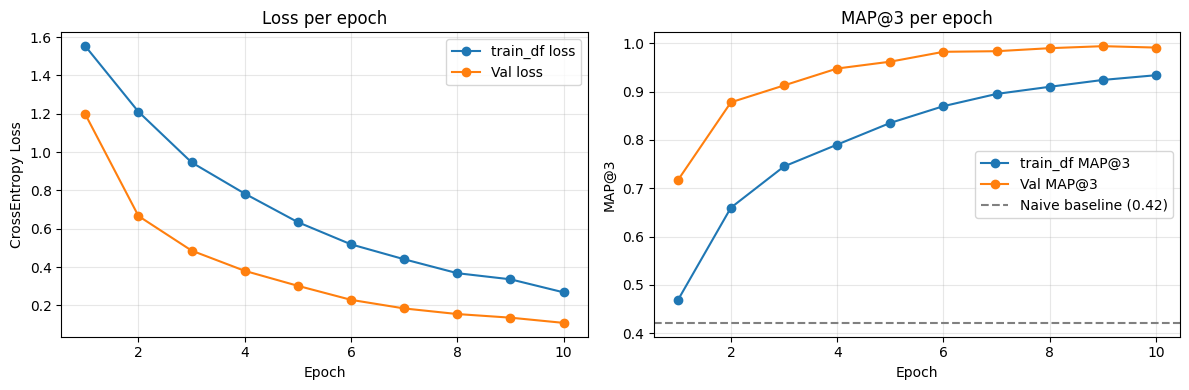

In [7]:
# ── Cell 7: Plot training curves ──────────────────────────────
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(history["train_loss"]) + 1)

ax1.plot(epochs, history["train_loss"], label="train_df loss", marker="o")
ax1.plot(epochs, history["val_loss"],   label="Val loss",   marker="o")
ax1.set_title("Loss per epoch")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("CrossEntropy Loss")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history["train_map"], label="train_df MAP@3", marker="o")
ax2.plot(epochs, history["val_map"],   label="Val MAP@3",   marker="o")
ax2.axhline(0.4213, linestyle="--", color="gray", label="Naive baseline (0.42)")
ax2.set_title("MAP@3 per epoch")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("MAP@3")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# ── Cell 8: Generate Submission ───────────────────────────────

# Load best model weights
model.load_state_dict(best_model_state)

IDX_TO_LABEL = {0:"A", 1:"B", 2:"C", 3:"D", 4:"E"}

@torch.no_grad()
def generate_submission(model, loader, test_df):
    model.eval()
    all_preds = []

    for batch in loader:
        logits = model(
            batch["prompt_ids"].to(DEVICE),
            batch["prompt_len"].to(DEVICE),
            batch["option_ids"].to(DEVICE),
            batch["option_lens"].to(DEVICE),
        )
        # Rank all 5, take top 3 indices
        ranked = torch.argsort(logits, dim=-1, descending=True)  # (B, 5)
        top3   = ranked[:, :3].tolist()
        for t in top3:
            pred_str = " ".join([IDX_TO_LABEL[i] for i in t])
            all_preds.append(pred_str)

    submission = pd.DataFrame({
        "ID"        : test_df["id"].values,
        "Prediction": all_preds
    })
    return submission

submission = generate_submission(model, test_loader, test_df)
submission.to_csv("submission.csv", index=False)

print(f"Submission saved: {len(submission)} rows")
print(submission.head(10))

Submission saved: 500 rows
   ID Prediction
0   1      A C D
1   2      B D A
2   3      B D E
3   4      E C D
4   5      C A B
5   6      D C B
6   7      E D C
7   8      B E A
8   9      A C E
9  10      B E A
